# Medical Insurance Cost Prediction using Multiple Linear Regression

## 1. Import Libraries

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 2. Load Dataset

In [32]:
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 3. Data Understanding

In [33]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (1338, 7)

Column Names:
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

Data Types:
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object


In [34]:
numerical_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = df.select_dtypes(include=["object", "string"]).columns.tolist()
target_variable = "charges"

print("Numerical Features:", numerical_features)
print("Categorical Features:", categorical_features)
print("Target Variable:", target_variable)

Numerical Features: ['age', 'bmi', 'children', 'charges']
Categorical Features: ['sex', 'smoker', 'region']
Target Variable: charges


## 4. Data Preprocessing

In [35]:
print(df.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [36]:
encoder = LabelEncoder()

df["sex"] = encoder.fit_transform(df["sex"])
df["smoker"] = encoder.fit_transform(df["smoker"])
df["region"] = encoder.fit_transform(df["region"])

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


In [37]:
X = df[["age", "sex", "bmi", "children", "smoker", "region"]]
y = df["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (1070, 6)
Testing Data: (268, 6)


## 5. Model Development

In [38]:
model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Model trained successfully.")

Model trained successfully.


## 6. Model Evaluation

In [39]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("R2 Score:", r2)

Mean Absolute Error (MAE): 4186.508898366432
Mean Squared Error (MSE): 33635210.431178406
R2 Score: 0.7833463107364539


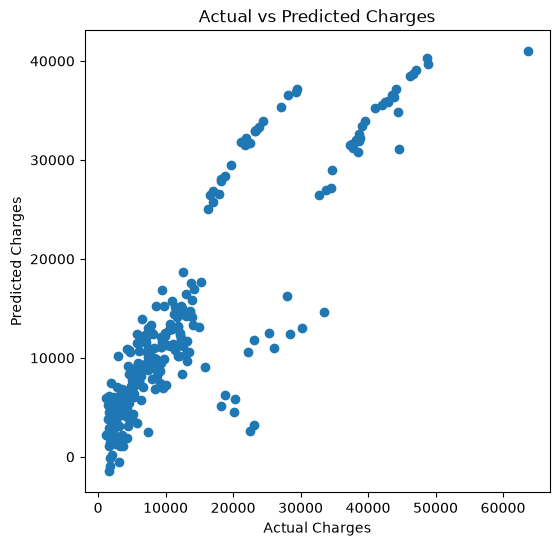

In [40]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges")
plt.show()

## 7. Observations

1. The model predicts insurance charges reasonably well, with an R² score close to 0.78.

2. Most predicted values are close to the actual values, although some higher insurance charges show larger prediction errors.

3. The scatter plot shows a positive relationship between actual and predicted charges, indicating that the model captures the overall trend.

## 8. Conclusion

This project developed a Multiple Linear Regression model to predict medical insurance charges using age, sex, BMI, number of children, smoker status, and region. The model was trained after preprocessing the data and achieved a good R² score, showing that it can explain a significant portion of the variation in insurance charges. Among all the features, smoker status has a strong impact on insurance cost, while age and BMI also influence the prediction. However, Linear Regression assumes a linear relationship between variables, which may not fully capture complex patterns in the data. More advanced machine learning models could improve prediction accuracy for this problem.